In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from preprocessing import add_remaining_useful_life, add_rolling_features

# Configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
columns = ['unit', 'cycle', 'setting1', 'setting2', 'setting3'] + \
          [f'sensor{i}' for i in range(1, 22)]

train = pd.read_csv('../data/train_FD001.txt', sep=' ', header=None)
train.drop(train.columns[[26, 27]], axis=1, inplace=True)
train.columns = columns

print(f"✓ Data loaded: {train.shape}")
print(f"✓ Preprocessing module imported!")
train.head()

✓ Data loaded: (20631, 26)
✓ Preprocessing module imported!


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


✓ RUL calculated!

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


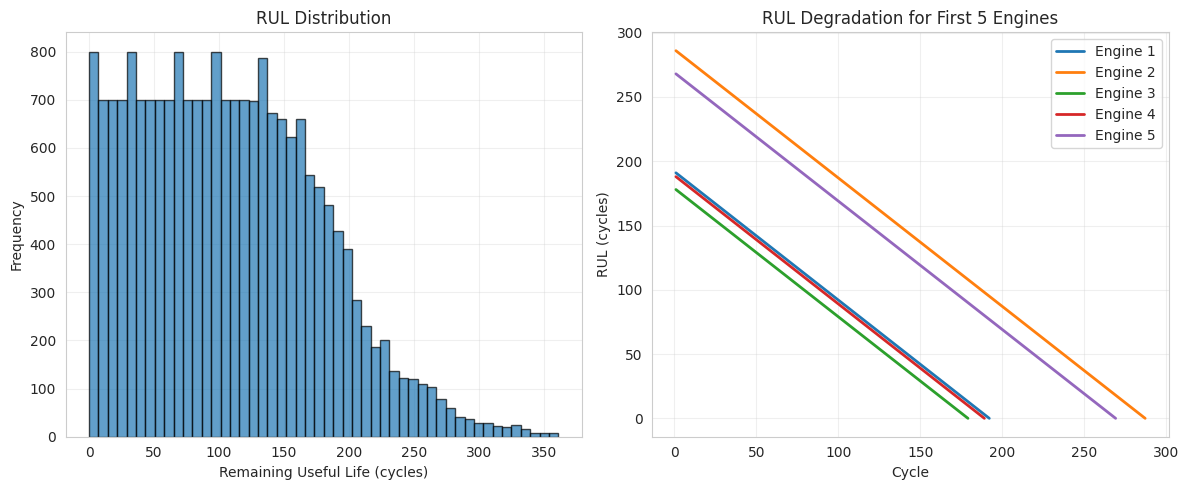

In [2]:
# Add RUL (target variable)
train = add_remaining_useful_life(train)

print("✓ RUL calculated!")
print(f"\nRUL statistics:")
print(train['RUL'].describe())

# Visualize RUL distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(train['RUL'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Remaining Useful Life (cycles)')
plt.ylabel('Frequency')
plt.title('RUL Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
# Show RUL for first 5 engines
for engine in range(1, 6):
    engine_data = train[train['unit'] == engine]
    plt.plot(engine_data['cycle'], engine_data['RUL'], 
             label=f'Engine {engine}', linewidth=2)

plt.xlabel('Cycle')
plt.ylabel('RUL (cycles)')
plt.title('RUL Degradation for First 5 Engines')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Select important sensors (from our exploration)
important_sensors = ['sensor2', 'sensor3', 'sensor4', 'sensor7', 
                     'sensor11', 'sensor12', 'sensor15', 'sensor20']

# Add rolling features
print("Adding rolling features (this may take a moment)...")
train = add_rolling_features(train, important_sensors, window=5)

print(f"✓ Rolling features added!")
print(f"New shape: {train.shape}")
print(f"\nNew columns:")
print([col for col in train.columns if 'rolling' in col])

train.head()

Adding rolling features (this may take a moment)...
✓ Rolling features added!
New shape: (20631, 43)

New columns:
['sensor2_rolling_mean', 'sensor2_rolling_std', 'sensor3_rolling_mean', 'sensor3_rolling_std', 'sensor4_rolling_mean', 'sensor4_rolling_std', 'sensor7_rolling_mean', 'sensor7_rolling_std', 'sensor11_rolling_mean', 'sensor11_rolling_std', 'sensor12_rolling_mean', 'sensor12_rolling_std', 'sensor15_rolling_mean', 'sensor15_rolling_std', 'sensor20_rolling_mean', 'sensor20_rolling_std']


,unit,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor7_rolling_mean,sensor7_rolling_std,sensor11_rolling_mean,sensor11_rolling_std,sensor12_rolling_mean,sensor12_rolling_std,sensor15_rolling_mean,sensor15_rolling_std,sensor20_rolling_mean,sensor20_rolling_std
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,554.360000,0.000000,47.470,0.000000,521.660,0.000000,8.419500,0.000000,39.060000,0.000000
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,554.055000,0.431335,47.480,0.014142,521.970,0.438406,8.425650,0.008697,39.030000,0.042426
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,554.123333,0.327159,47.410,0.121655,522.120,0.404475,8.423033,0.007640,39.003333,0.055076
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,554.205000,0.313103,47.340,0.171659,522.305,0.495950,8.409325,0.028117,38.972500,0.076322
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,554.164000,0.286234,47.328,0.151063,522.282,0.432574,8.413340,0.025953,38.958000,0.073621


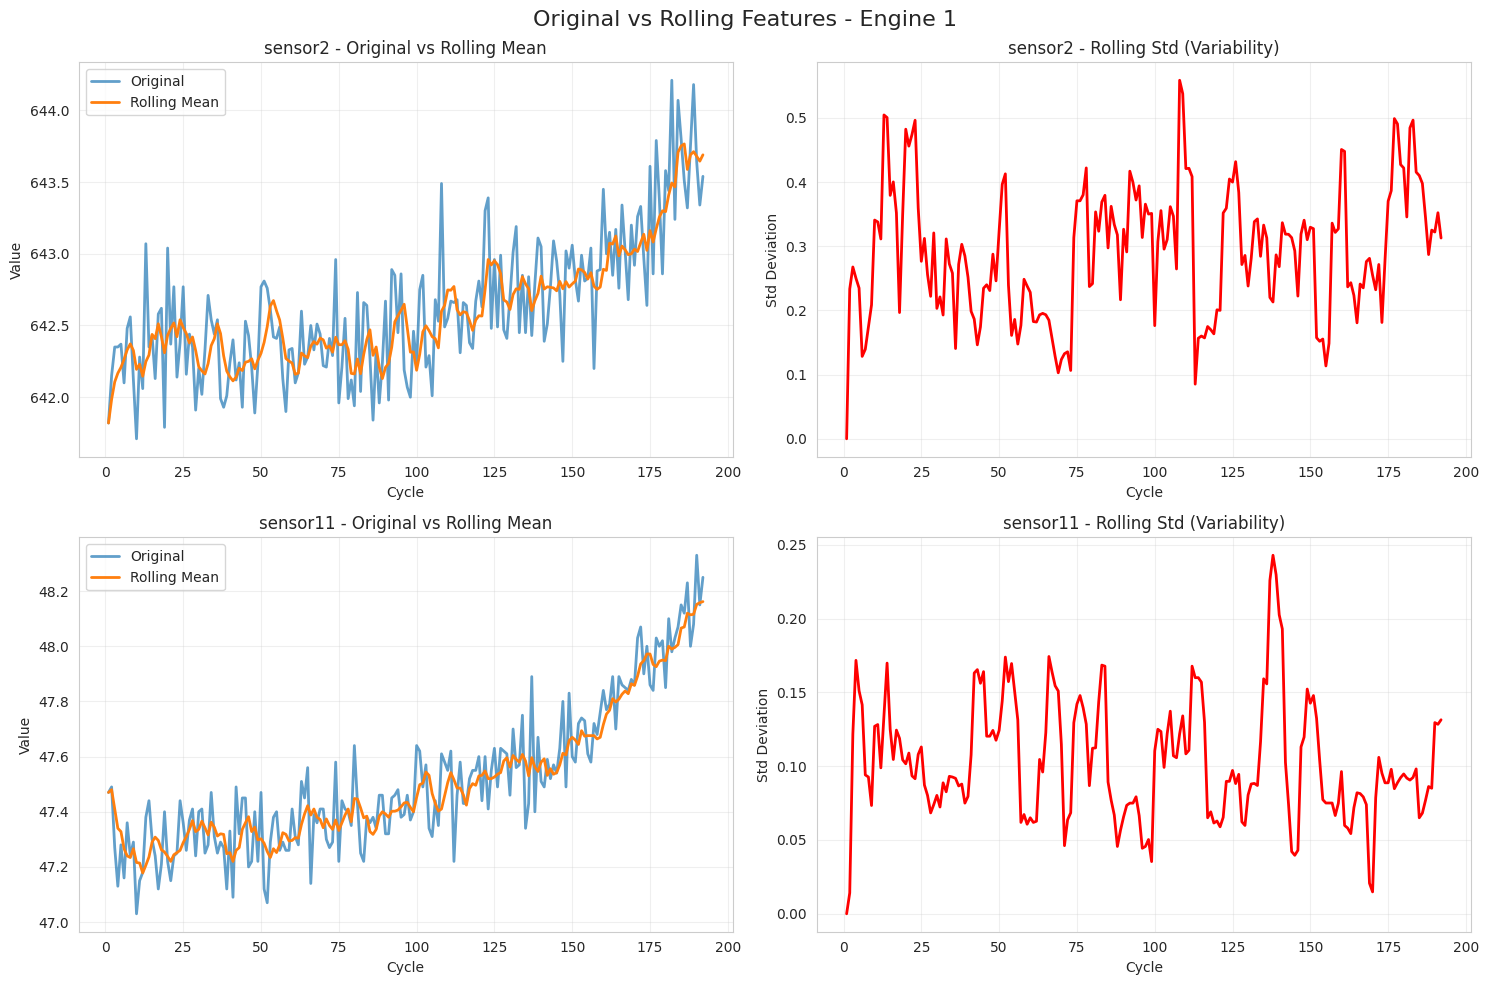

✓ Rolling features smooth the noise and capture trends!


In [4]:
# Compare original vs rolling features for Engine 1
engine_id = 1
engine_data = train[train['unit'] == engine_id]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Original vs Rolling Features - Engine {engine_id}', fontsize=16)

sensors_to_compare = ['sensor2', 'sensor11']

for idx, sensor in enumerate(sensors_to_compare):
    # Original sensor
    ax1 = axes[idx, 0]
    ax1.plot(engine_data['cycle'], engine_data[sensor], 
             label='Original', linewidth=2, alpha=0.7)
    ax1.plot(engine_data['cycle'], engine_data[f'{sensor}_rolling_mean'], 
             label='Rolling Mean', linewidth=2)
    ax1.set_xlabel('Cycle')
    ax1.set_ylabel('Value')
    ax1.set_title(f'{sensor} - Original vs Rolling Mean')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Rolling std (variability)
    ax2 = axes[idx, 1]
    ax2.plot(engine_data['cycle'], engine_data[f'{sensor}_rolling_std'], 
             color='red', linewidth=2)
    ax2.set_xlabel('Cycle')
    ax2.set_ylabel('Std Deviation')
    ax2.set_title(f'{sensor} - Rolling Std (Variability)')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Rolling features smooth the noise and capture trends!")